In [ ]:
sfrom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Available Person IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


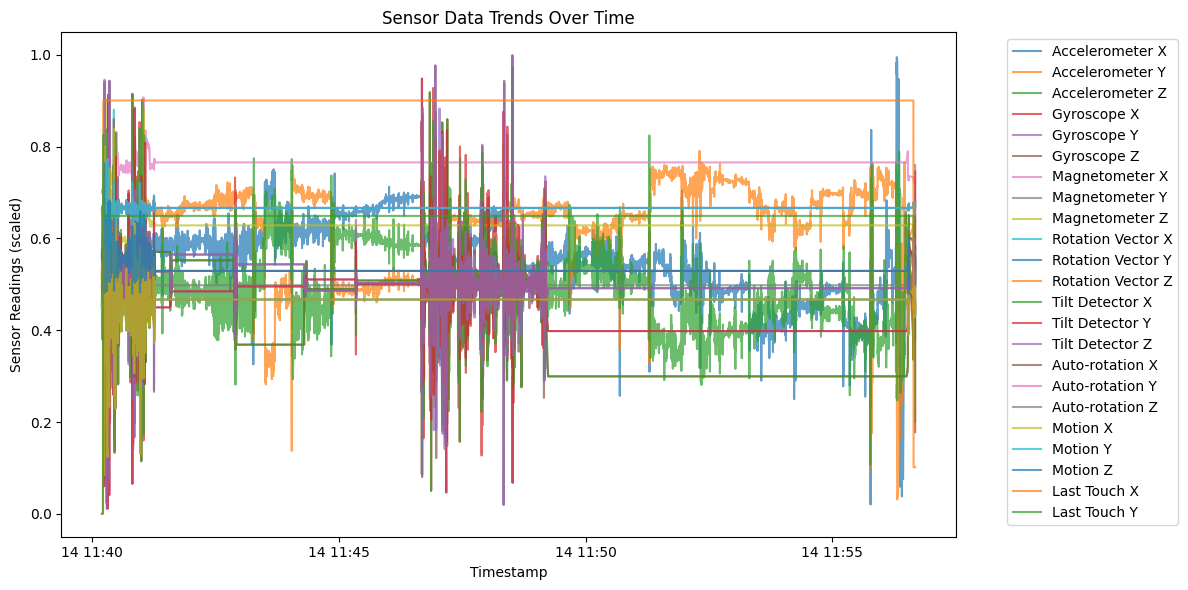

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/content/drive/MyDrive/Major Project/Combined Datas/merged_data_preprocessed_sample.csv"
df_preprocessed = pd.read_csv(data_path)
df_preprocessed['Timestamp'] = pd.to_datetime(df_preprocessed['Timestamp'])

if 'Person' in df_preprocessed.columns:
    persons = df_preprocessed['Person'].unique()
    print("Available Person IDs:", persons)
    df_viz = df_preprocessed[df_preprocessed['Person'] == persons[0]]
else:
    df_viz = df_preprocessed
sensor_columns = df_preprocessed.columns.drop(['Person', 'Timestamp'])

plt.figure(figsize=(12, 6))
for col in sensor_columns:
    plt.plot(df_viz['Timestamp'], df_viz[col], label=col, alpha=0.7)

plt.xlabel('Timestamp')
plt.ylabel('Sensor Readings (scaled)')
plt.title('Sensor Data Trends Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Selected Persons: [6, 1]


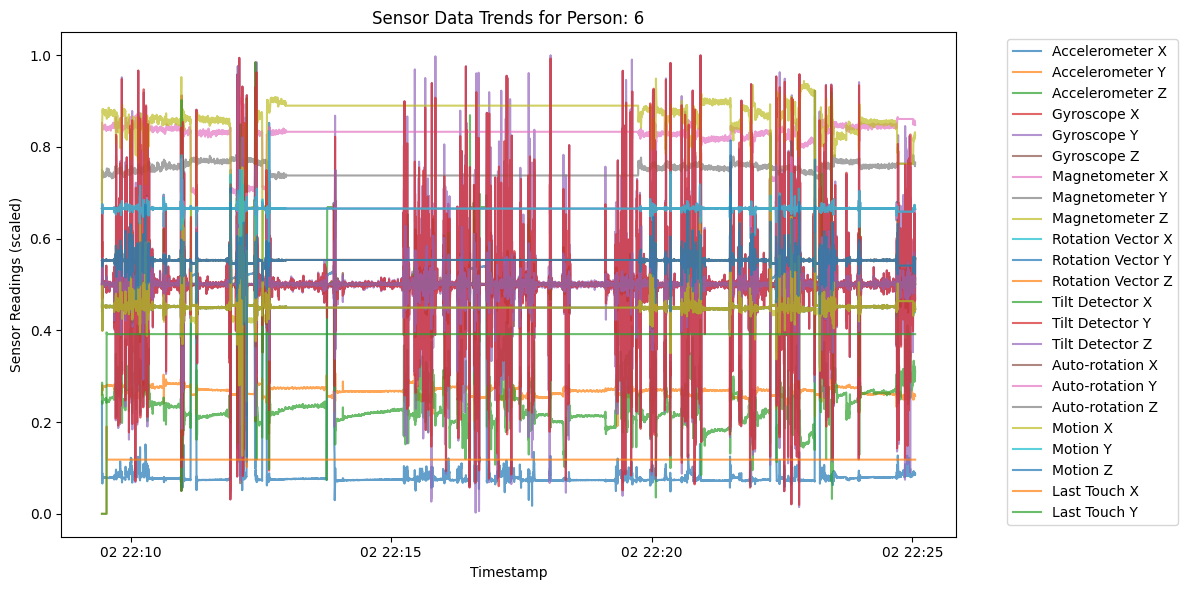

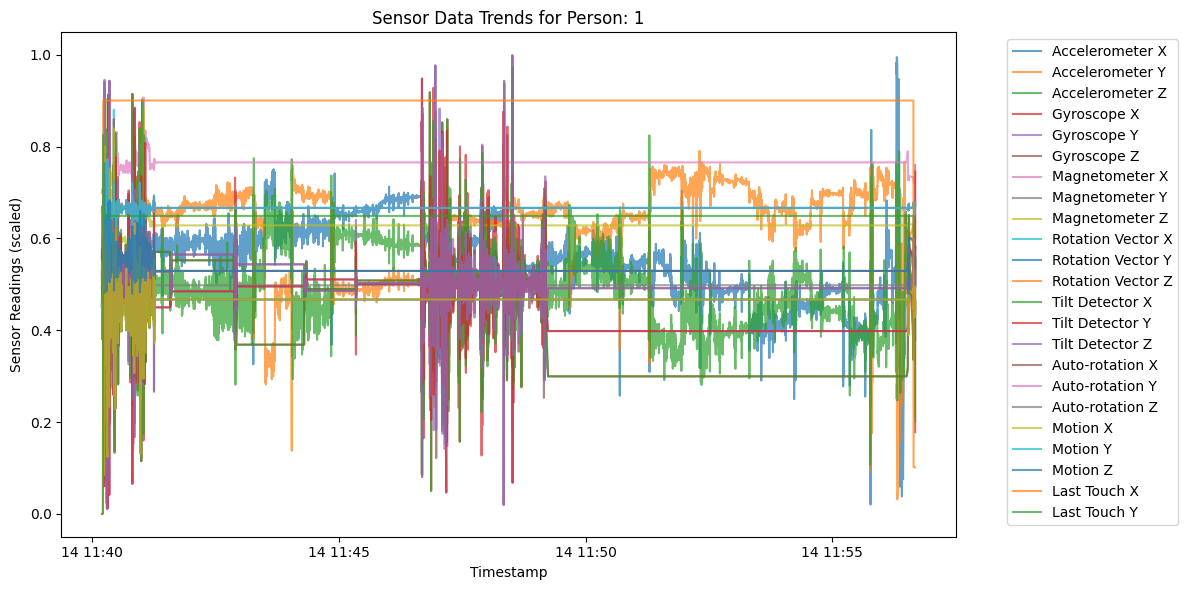

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import random

data_path = "/content/drive/MyDrive/Major Project/Combined Datas/merged_data_preprocessed_sample.csv"
df_preprocessed = pd.read_csv(data_path)
df_preprocessed['Timestamp'] = pd.to_datetime(df_preprocessed['Timestamp'])
persons = df_preprocessed['Person'].unique()
selected_persons = random.sample(list(persons), 2)
print("Selected Persons:", selected_persons)
sensor_columns = df_preprocessed.columns.drop(['Person', 'Timestamp'])

for person in selected_persons:
    person_df = df_preprocessed[df_preprocessed['Person'] == person].copy()

    plt.figure(figsize=(12, 6))
    for col in sensor_columns:
        plt.plot(person_df['Timestamp'], person_df[col], label=col, alpha=0.7)

    plt.xlabel('Timestamp')
    plt.ylabel('Sensor Readings (scaled)')
    plt.title(f'Sensor Data Trends for Person: {person}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
tf.keras.mixed_precision.set_global_policy('mixed_float16')

data_path = "/content/drive/MyDrive/Major Project/Combined Datas/merged_data_preprocessed_sample.csv"
df = pd.read_csv(data_path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

sensor_columns = [
    'Accelerometer X', 'Accelerometer Y', 'Accelerometer Z',
    'Gyroscope X', 'Gyroscope Y', 'Gyroscope Z',
    'Magnetometer X', 'Magnetometer Y', 'Magnetometer Z',
    'Rotation Vector X', 'Rotation Vector Y', 'Rotation Vector Z',
    'Tilt Detector X', 'Tilt Detector Y', 'Tilt Detector Z',
    'Auto-rotation X', 'Auto-rotation Y', 'Auto-rotation Z',
    'Motion X', 'Motion Y', 'Motion Z',
    'Last Touch X', 'Last Touch Y'
]
print("Sensor columns:", sensor_columns)
le = LabelEncoder()
df['Person_encoded'] = le.fit_transform(df['Person'])
num_classes = len(le.classes_)
print("Number of classes:", num_classes)
sequence_length = 100

def sequence_generator(df, sensor_columns, sequence_length, stride=5):
    """
    For each person (grouped by 'Person'), sorted by Timestamp,
    yield overlapping sequences of sensor readings and the corresponding label.
    If a person's data has fewer rows than sequence_length, pad with zeros to form one sequence.
    The 'stride' parameter controls the step size between consecutive sequences.
    """
    for person, group in df.groupby('Person'):
        group = group.sort_values('Timestamp')
        sensor_data = group[sensor_columns].values.astype('float32')
        label = group['Person_encoded'].iloc[0]
        n = sensor_data.shape[0]
        if n < sequence_length:
            padded = np.zeros((sequence_length, len(sensor_columns)), dtype='float32')
            padded[:n] = sensor_data
            yield padded, label
        else:
            for i in range(0, n - sequence_length + 1, stride):
                yield sensor_data[i:i+sequence_length], label

output_signature = (
    tf.TensorSpec(shape=(sequence_length, len(sensor_columns)), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int32)
)

sample_count = sum(1 for _ in sequence_generator(df, sensor_columns, sequence_length, stride=5))
print("Total samples:", sample_count)
train_count = int(0.8 * sample_count)
print("Train samples:", train_count)

BATCH_SIZE = 128

dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(df, sensor_columns, sequence_length, stride=5),
    output_signature=output_signature
)

dataset = dataset.shuffle(20000)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

train_dataset = dataset.take(train_count // BATCH_SIZE).repeat()
val_dataset = dataset.skip(train_count // BATCH_SIZE)

steps_per_epoch = train_count // BATCH_SIZE
validation_steps = (sample_count - train_count) // BATCH_SIZE
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)

model = Sequential([
    GRU(64, input_shape=(sequence_length, len(sensor_columns)),
        return_sequences=True,
        kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    GRU(32, kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    Dense(num_classes, activation='softmax', dtype='float32')
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs=50,
                    steps_per_epoch=steps_per_epoch,
                    validation_steps=validation_steps,
                    callbacks=callbacks)

loss, accuracy = model.evaluate(val_dataset, steps=validation_steps)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Sensor columns: ['Accelerometer X', 'Accelerometer Y', 'Accelerometer Z', 'Gyroscope X', 'Gyroscope Y', 'Gyroscope Z', 'Magnetometer X', 'Magnetometer Y', 'Magnetometer Z', 'Rotation Vector X', 'Rotation Vector Y', 'Rotation Vector Z', 'Tilt Detector X', 'Tilt Detector Y', 'Tilt Detector Z', 'Auto-rotation X', 'Auto-rotation Y', 'Auto-rotation Z', 'Motion X', 'Motion Y', 'Motion Z', 'Last Touch X', 'Last Touch Y']
Number of classes: 25
Total samples: 43257
Train samples: 34605
Steps per epoch: 270
Validation steps: 67


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 100, 64)             │          17,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │             425 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,449 (107.22 KB)

 Trainable params: 27,449 (107.22 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 185s 638ms/step - accuracy: 0.1304 - loss: 2.9527 - val_accuracy: 0.3834 - val_loss: 1.8077 - learning_rate: 5.0000e-04
Epoch 2/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 195s 722ms/step - accuracy: 0.4563 - loss: 1.8015 - val_accuracy: 0.5285 - val_loss: 1.3250 - learning_rate: 5.0000e-04
Epoch 3/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 203s 752ms/step - accuracy: 0.5839 - loss: 1.3290 - val_accuracy: 0.6515 - val_loss: 1.0379 - learning_rate: 5.0000e-04
Epoch 4/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 169s 626ms/step - accuracy: 0.6763 - loss: 1.0597 - val_accuracy: 0.7913 - val_loss: 0.7895 - learning_rate: 5.0000e-04
Epoch 5/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 194s 720ms/step - accuracy: 0.7428 - loss: 0.8878 - val_accuracy: 0.8160 - val_loss: 0.6556 - learning_rate: 5.0000e-04
Epoch 6/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 172s 639ms/step - accuracy: 0.7800 - loss: 0.7778 - val_accuracy: 0.8218 - val_loss: 0.5648 - learning_rate: 5.0000e-04
Epoch 7/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.2066420018672943
Test Accuracy: 0.9043843150138855


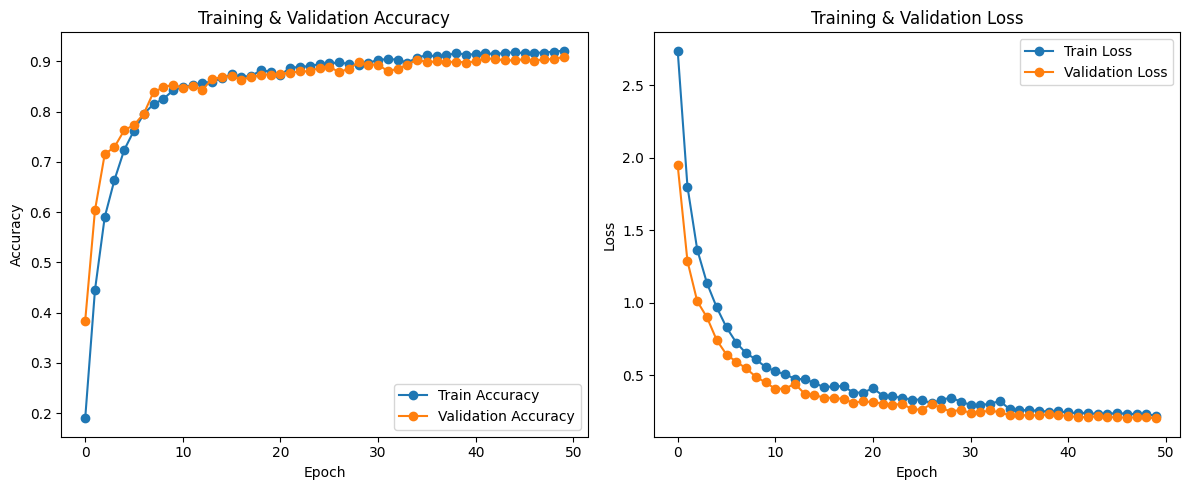

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
4/4 ━━━━━━━━

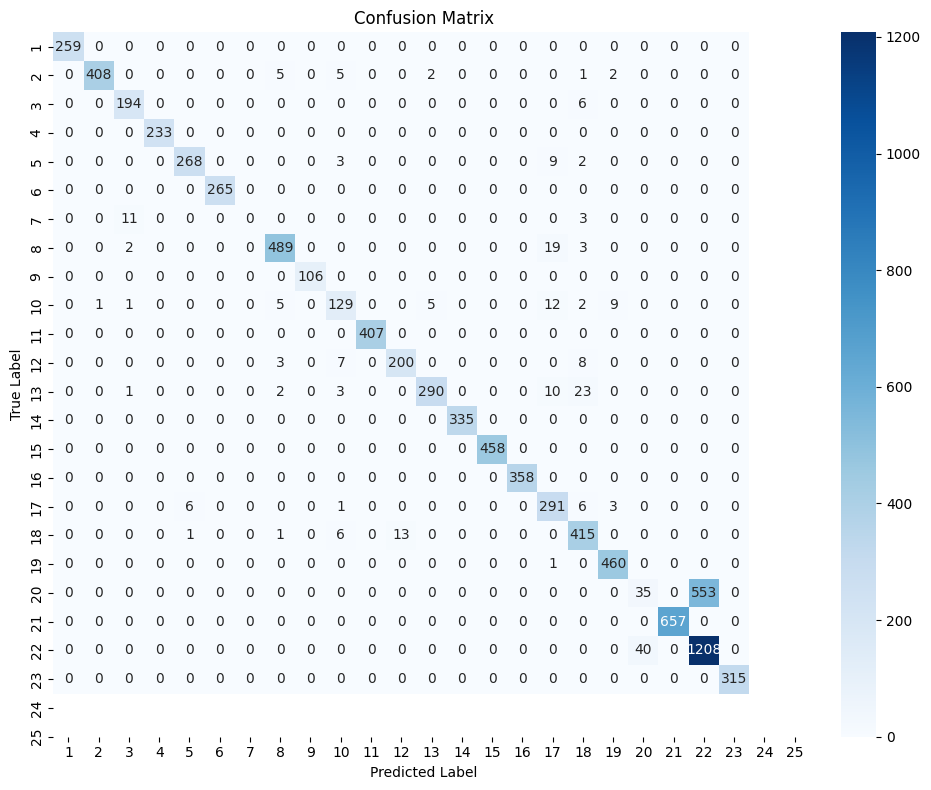

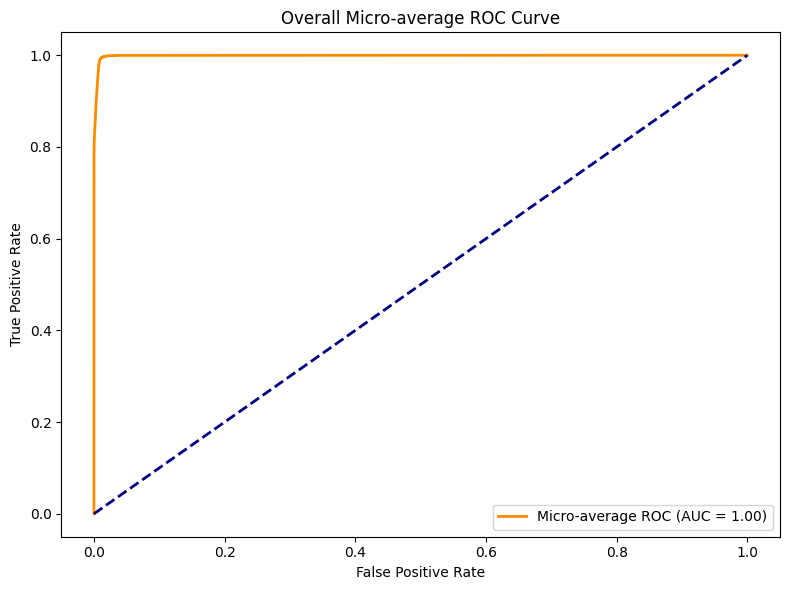

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

y_true_list = []
y_pred_prob_list = []
for X_batch, y_batch in val_dataset:
    y_true_list.append(y_batch)
    y_pred_prob_list.append(model.predict(X_batch))

y_true = tf.concat(y_true_list, axis=0).numpy()
y_pred_prob = np.concatenate(y_pred_prob_list, axis=0)
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall Micro-average ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
